Aggregation by Simplified Style (across all approaches):
+-------------------------+--------------------+------+--------+---------+-------+-------------------+
|          Style          |   Question Type    | Mean | Median | Std Dev | Count | Diff from Control |
+-------------------------+--------------------+------+--------+---------+-------+-------------------+
|  Conditional statement  | 24-36 months ahead | 2.23 |  2.2   |  0.05   |  300  |       -0.22       |
|  Conditional statement  |   Next 12 months   | 2.7  |  2.6   |  0.19   |  300  |       -0.49       |
|    Long-term horizon    | 24-36 months ahead | 2.23 |  2.2   |  0.14   |  300  |       -0.22       |
|    Long-term horizon    |   Next 12 months   | 2.73 |  2.5   |  0.35   |  300  |       -0.46       |
|     No information      | 24-36 months ahead | 2.45 |  2.5   |  0.07   |  100  |        0.0        |
|     No information      |   Next 12 months   | 3.19 |  3.2   |  0.03   |  100  |        0.0        |
|   Short-term h

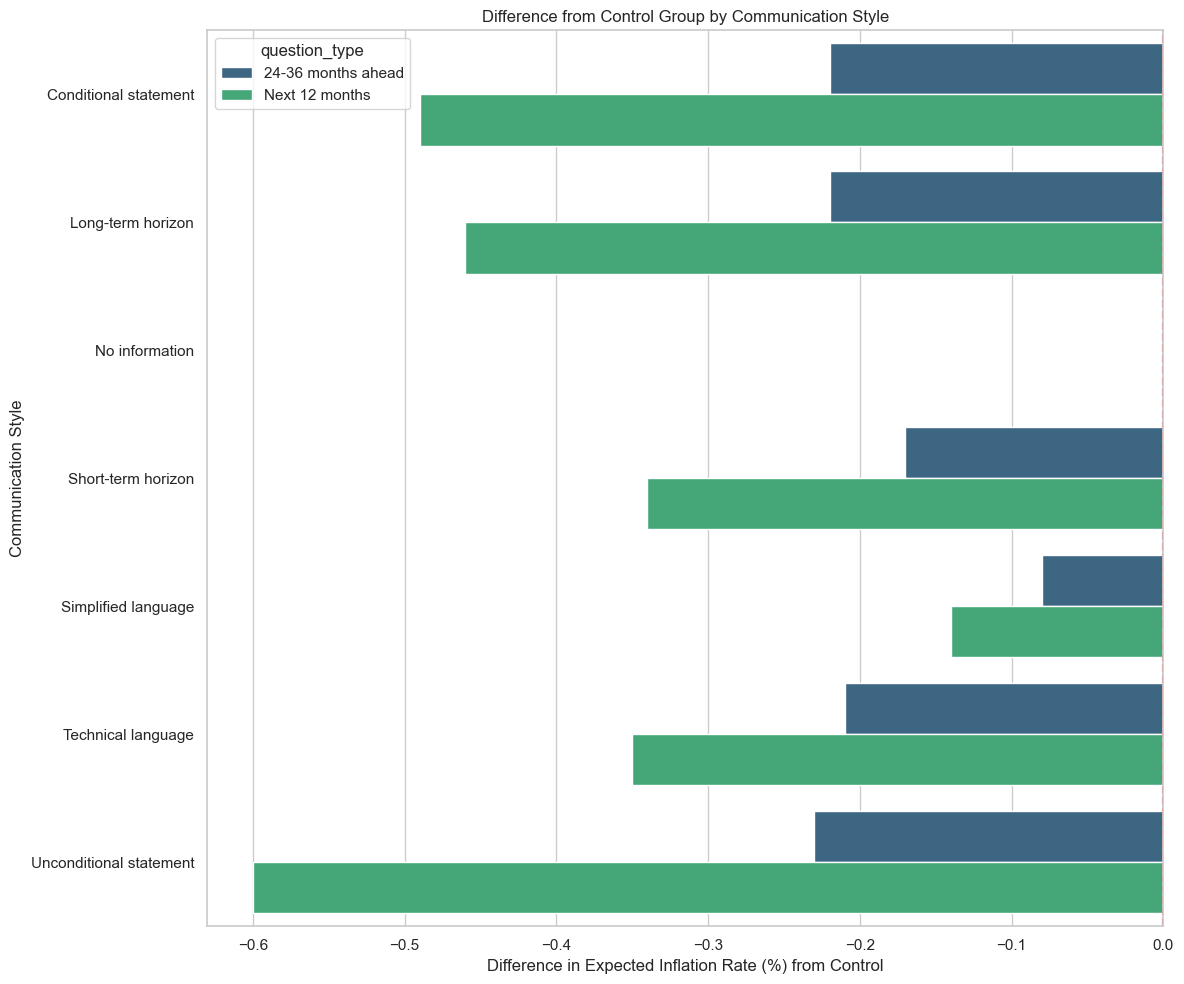

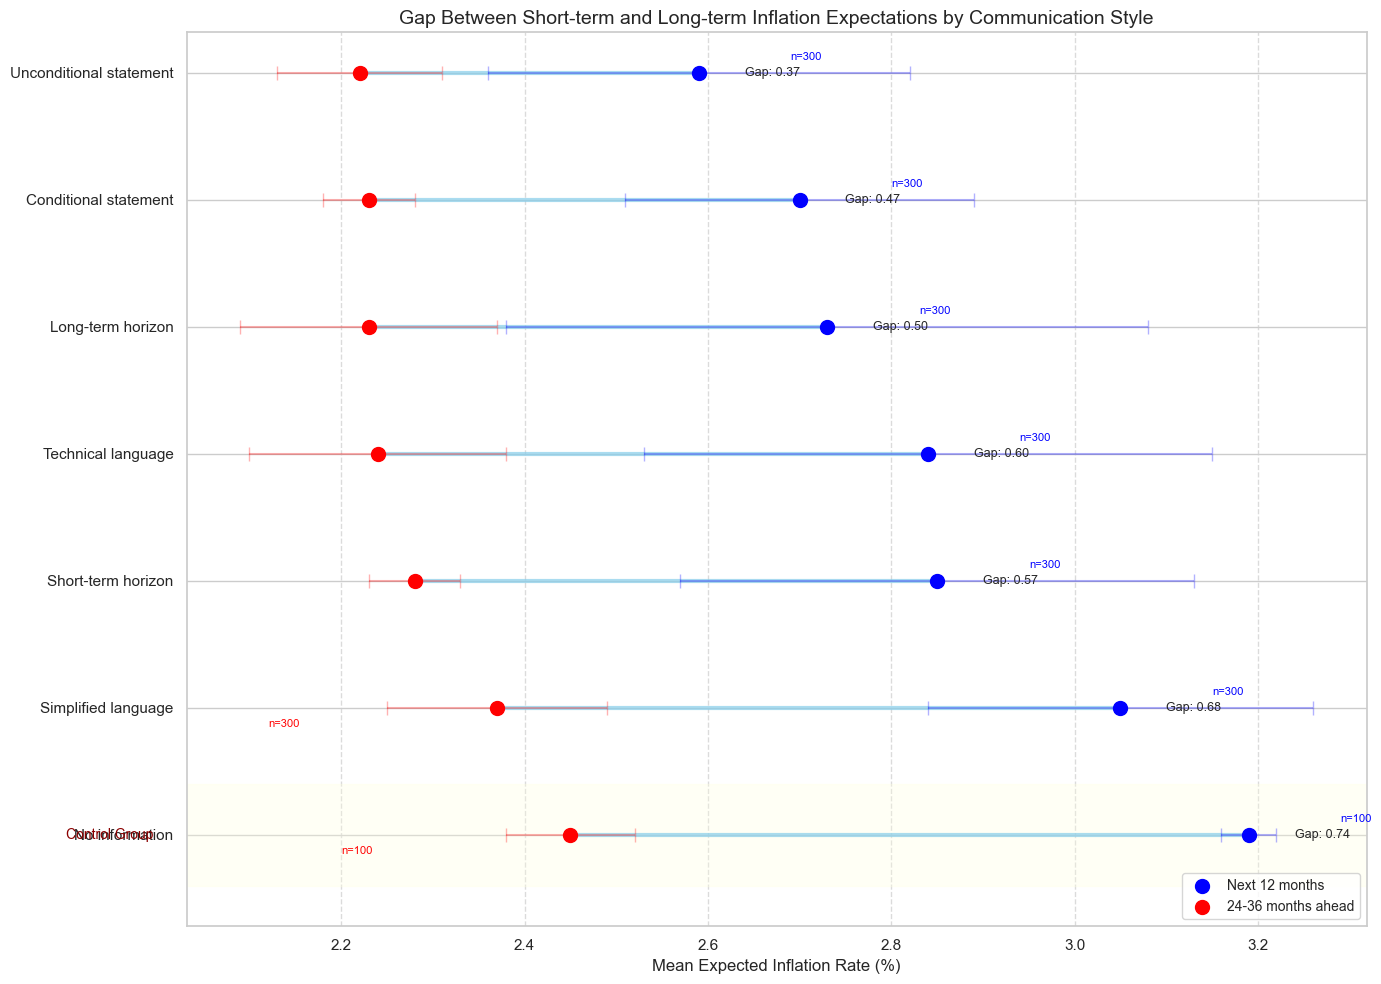

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# Load the original CSV file
df = pd.read_csv('communication_treatments.csv')

# Ensure the response column is numeric
df['response'] = pd.to_numeric(df['response'], errors='coerce')

# Create a simplified version of the question column
df['question_type'] = df['question'].apply(
    lambda x: 'Next 12 months' if 'next 12 months' in x else '24-36 months ahead'
)

# Extract the main communication approach and style from treatment_description
# Use regex to handle the different formats
df['approach'] = df['treatment_description'].str.extract(r'(^[^-]+)(?:-|$)')[0].str.strip()
df['style'] = df['treatment_description'].str.extract(r'(?:[^-]+-\s*)(.*$)')[0]
df['style'] = df['style'].str.strip()

# Handle the Control case which doesn't follow the pattern
mask = df['treatment_description'] == 'Control with no information'
df.loc[mask, 'approach'] = 'Control'
df.loc[mask, 'style'] = 'No information'

# Create a new "simple style" column that removes the approach prefix
# This will allow aggregation by style type regardless of approach
df['simple_style'] = df['style'].str.replace(r'^\w+ - ', '', regex=True)
df.loc[mask, 'simple_style'] = 'No information'  # Keep the control group as is

# Get the control group data for comparison
control_data = df[df['style'] == 'No information'].groupby('question_type')['response'].mean().to_dict()

# Aggregate by simplified style across all approaches
style_simple_aggregate = df.groupby(['simple_style', 'question_type']).agg(
    mean=('response', 'mean'),
    median=('response', 'median'),
    std=('response', 'std'),
    count=('response', 'count')
).reset_index()

# Add a column comparing to the control group
style_simple_aggregate['diff_from_control'] = style_simple_aggregate.apply(
    lambda row: row['mean'] - control_data[row['question_type']], axis=1
)

# Round for better display
style_simple_aggregate = style_simple_aggregate.round(2)

print("Aggregation by Simplified Style (across all approaches):")
print(tabulate(style_simple_aggregate, 
               headers=['Style', 'Question Type', 'Mean', 'Median', 'Std Dev', 'Count', 'Diff from Control'], 
               tablefmt='pretty', showindex=False))

# Calculate the difference between short-term and long-term expectations for each style
style_pivot = style_simple_aggregate.pivot(index='simple_style', columns='question_type', values=['mean', 'std', 'count'])
style_pivot.columns = [f"{col[1]} ({col[0]})" for col in style_pivot.columns]
style_pivot['Gap'] = style_pivot['Next 12 months (mean)'] - style_pivot['24-36 months ahead (mean)']
style_pivot['Gap Diff from Control'] = style_pivot['Gap'] - (control_data['Next 12 months'] - control_data['24-36 months ahead'])
style_pivot = style_pivot.sort_values('Gap', ascending=False).reset_index()

# Create a comprehensive table with all metrics
comprehensive_table = style_pivot.rename(columns={'simple_style': 'Style'})

print("\nRanking of Styles by Gap Between Short-term and Long-term Expectations (with Control Comparison):")
print(tabulate(comprehensive_table, headers='keys', tablefmt='pretty', showindex=False))

# Create a comparison to control for all styles
plt.figure(figsize=(12, 10))
ax = sns.barplot(x='diff_from_control', y='simple_style', hue='question_type', 
                data=style_simple_aggregate, palette='viridis')
plt.title('Difference from Control Group by Communication Style')
plt.xlabel('Difference in Expected Inflation Rate (%) from Control')
plt.ylabel('Communication Style')
plt.axvline(x=0, color='red', linestyle='--')
plt.tight_layout()
plt.savefig('style_diff_from_control.png')

# Create the enhanced lollipop chart
fig, ax = plt.subplots(figsize=(14, 10))

# Filter data for each question type
next_12_months = style_simple_aggregate[style_simple_aggregate['question_type'] == 'Next 12 months']
months_24_36 = style_simple_aggregate[style_simple_aggregate['question_type'] == '24-36 months ahead']

# Sort by the gap between short and long term expectations
sorted_styles = next_12_months.sort_values('mean', ascending=False)['simple_style'].values

# Reindex both dataframes based on this order
next_12_months = next_12_months.set_index('simple_style').reindex(sorted_styles).reset_index()
months_24_36 = months_24_36.set_index('simple_style').reindex(sorted_styles).reset_index()

# Plot the lollipops
ax.hlines(y=np.arange(len(sorted_styles)), xmin=months_24_36['mean'], xmax=next_12_months['mean'], 
         color='skyblue', alpha=0.7, linewidth=3)
ax.scatter(next_12_months['mean'], np.arange(len(sorted_styles)), color='blue', s=100, 
          label='Next 12 months', zorder=3)
ax.scatter(months_24_36['mean'], np.arange(len(sorted_styles)), color='red', s=100, 
          label='24-36 months ahead', zorder=3)

# Add standard deviation error bars
for i, (idx, row) in enumerate(next_12_months.iterrows()):
    ax.errorbar(row['mean'], i, xerr=row['std'], fmt='none', ecolor='blue', alpha=0.3, capsize=5)
for i, (idx, row) in enumerate(months_24_36.iterrows()):
    ax.errorbar(row['mean'], i, xerr=row['std'], fmt='none', ecolor='red', alpha=0.3, capsize=5)

# Add count information in annotations
for i, (idx, row) in enumerate(next_12_months.iterrows()):
    ax.annotate(f"n={row['count']}", xy=(row['mean'] + 0.1, i + 0.1), 
                fontsize=8, color='blue')
for i, (idx, row) in enumerate(months_24_36.iterrows()):
    ax.annotate(f"n={row['count']}", xy=(row['mean'] - 0.25, i - 0.15), 
                fontsize=8, color='red')

# Highlight the control group
control_idx = np.where(sorted_styles == 'No information')[0][0]
ax.axhspan(control_idx-0.4, control_idx+0.4, color='lightyellow', alpha=0.3, zorder=1)
ax.text(1.9, control_idx, 'Control Group', fontsize=10, verticalalignment='center', color='darkred')

# Add gap size as text
for i, style in enumerate(sorted_styles):
    gap = next_12_months.iloc[i]['mean'] - months_24_36.iloc[i]['mean']
    ax.text(next_12_months.iloc[i]['mean'] + 0.05, i, f"Gap: {gap:.2f}", 
            verticalalignment='center', fontsize=9)

# Add style names to the y-axis
plt.yticks(np.arange(len(sorted_styles)), sorted_styles)
plt.title('Gap Between Short-term and Long-term Inflation Expectations by Communication Style', fontsize=14)
plt.xlabel('Mean Expected Inflation Rate (%)', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('style_expectation_gap.png')

# Create an additional table with averages of all second parts (the style part)
# First, create a dataframe with just the main style categories (without approach prefixes)
df_simplified = df.copy()

# Create a comprehensive table with averages for all second parts
style_averages = df_simplified.groupby(['simple_style', 'question_type'])['response'].agg(
    mean=('mean'),
    median=('median'),
    std=('std'),
    count=('count')
).reset_index()

# Calculate the gap for each style
style_average_pivot = style_averages.pivot(index='simple_style', columns='question_type')
style_average_pivot.columns = [f"{col[1]}_{col[0]}" for col in style_average_pivot.columns]
style_average_pivot['gap'] = style_average_pivot['Next 12 months_mean'] - style_average_pivot['24-36 months ahead_mean']
style_average_pivot['diff_from_control'] = style_average_pivot['gap'] - (control_data['Next 12 months'] - control_data['24-36 months ahead'])
style_average_table = style_average_pivot.reset_index().round(2)

print("\nComprehensive Table of Style Averages (All Second Parts):")
print(tabulate(style_average_table, headers='keys', tablefmt='pretty', showindex=False))

# Save the tables to CSV
comprehensive_table.to_csv('comprehensive_style_analysis.csv', index=False)
style_average_table.to_csv('style_averages.csv', index=False)

print("\nAnalysis complete. The style_expectation_gap.png visualization has been created.")


Ranking of Styles by Gap Between Short-term and Long-term Expectations:
+-------------------------+----------------+--------------------+---------------------+
|          Style          | Next 12 months | 24-36 months ahead |         Gap         |
+-------------------------+----------------+--------------------+---------------------+
|     No information      |      3.19      |        2.45        | 0.7399999999999998  |
|   Simplified language   |      3.05      |        2.37        | 0.6799999999999997  |
|   Technical language    |      2.84      |        2.24        | 0.5999999999999996  |
|   Short-term horizon    |      2.85      |        2.28        | 0.5700000000000003  |
|    Long-term horizon    |      2.73      |        2.23        |         0.5         |
|  Conditional statement  |      2.7       |        2.23        | 0.4700000000000002  |
| Unconditional statement |      2.59      |        2.22        | 0.36999999999999966 |
+-------------------------+----------------+---

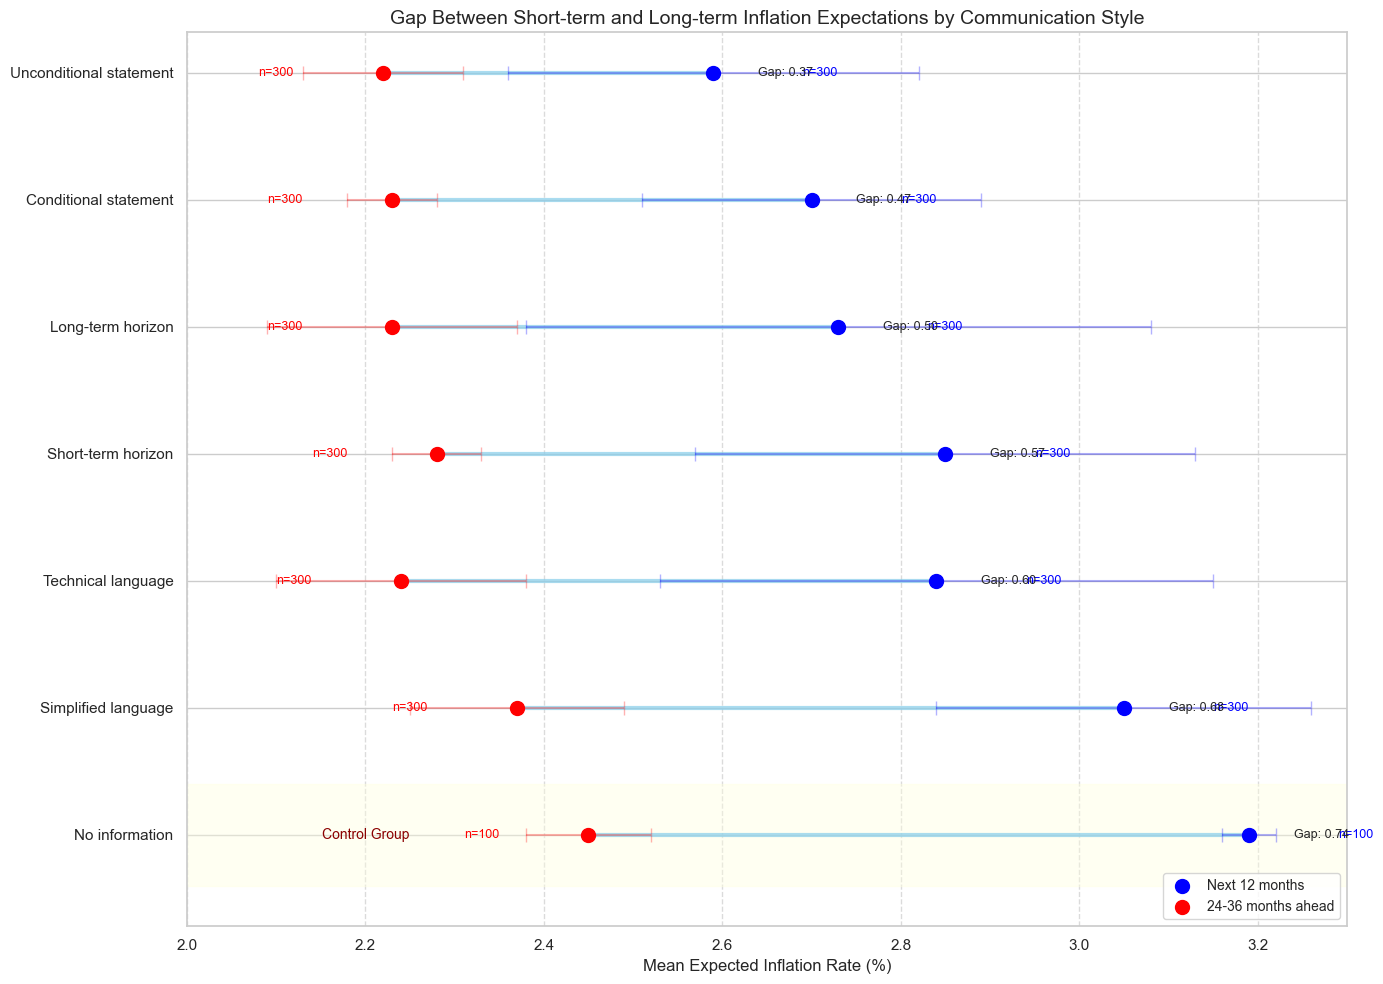

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# Load the original CSV file
df = pd.read_csv('communication_treatments.csv')

# Ensure the response column is numeric
df['response'] = pd.to_numeric(df['response'], errors='coerce')

# Create a simplified version of the question column
df['question_type'] = df['question'].apply(
    lambda x: 'Next 12 months' if 'next 12 months' in x else '24-36 months ahead'
)

# Extract the main communication approach and style from treatment_description
df['approach'] = df['treatment_description'].str.extract(r'(^[^-]+)(?:-|$)')[0].str.strip()
df['style'] = df['treatment_description'].str.extract(r'(?:[^-]+-\s*)(.*$)')[0]
df['style'] = df['style'].str.strip()

# Handle the Control case which doesn't follow the pattern
mask = df['treatment_description'] == 'Control with no information'
df.loc[mask, 'approach'] = 'Control'
df.loc[mask, 'style'] = 'No information'

# Create a new "simple style" column that extracts just the style part
# This will allow aggregation by style type regardless of approach
df['simple_style'] = df['style'].str.replace(r'^\w+ - ', '', regex=True)
df.loc[mask, 'simple_style'] = 'No information'  # Keep the control group as is

# Aggregate by simplified style across all approaches
style_simple_aggregate = df.groupby(['simple_style', 'question_type']).agg(
    mean=('response', 'mean'),
    median=('response', 'median'),
    std=('response', 'std'),
    count=('response', 'count')
).reset_index()

# Round for better display
style_simple_aggregate = style_simple_aggregate.round(2)

# Calculate the difference between short-term and long-term expectations for each style
style_pivot = style_simple_aggregate.pivot(index='simple_style', columns='question_type', values=['mean', 'std', 'count'])
style_pivot.columns = [f"{col[1]} ({col[0]})" for col in style_pivot.columns]
style_pivot['Gap'] = style_pivot['Next 12 months (mean)'] - style_pivot['24-36 months ahead (mean)']

# Sort by gap size from largest to smallest
style_pivot = style_pivot.sort_values('Gap', ascending=False).reset_index()

# Extract the sorted order of styles
sorted_styles = style_pivot['simple_style'].tolist()

# Create the improved lollipop chart
fig, ax = plt.subplots(figsize=(14, 10))

# Filter data for each question type
next_12_months = style_simple_aggregate[style_simple_aggregate['question_type'] == 'Next 12 months']
months_24_36 = style_simple_aggregate[style_simple_aggregate['question_type'] == '24-36 months ahead']

# Map styles to their position based on the sorted order
style_positions = {style: i for i, style in enumerate(sorted_styles)}

# Create new DataFrames with the sorted data
sorted_next_12 = pd.DataFrame()
sorted_months_24_36 = pd.DataFrame()

for style in sorted_styles:
    sorted_next_12 = pd.concat([sorted_next_12, next_12_months[next_12_months['simple_style'] == style]])
    sorted_months_24_36 = pd.concat([sorted_months_24_36, months_24_36[months_24_36['simple_style'] == style]])

# Reset indices to match the position
sorted_next_12 = sorted_next_12.reset_index(drop=True)
sorted_months_24_36 = sorted_months_24_36.reset_index(drop=True)

# Plot the lollipops
y_positions = np.arange(len(sorted_styles))
ax.hlines(y=y_positions, xmin=sorted_months_24_36['mean'], xmax=sorted_next_12['mean'], 
         color='skyblue', alpha=0.7, linewidth=3)
ax.scatter(sorted_next_12['mean'], y_positions, color='blue', s=100, 
          label='Next 12 months', zorder=3)
ax.scatter(sorted_months_24_36['mean'], y_positions, color='red', s=100, 
          label='24-36 months ahead', zorder=3)

# Add standard deviation error bars
for i, (_, row) in enumerate(sorted_next_12.iterrows()):
    ax.errorbar(row['mean'], i, xerr=row['std'], fmt='none', ecolor='blue', alpha=0.3, capsize=5)
for i, (_, row) in enumerate(sorted_months_24_36.iterrows()):
    ax.errorbar(row['mean'], i, xerr=row['std'], fmt='none', ecolor='red', alpha=0.3, capsize=5)

# Add count information in annotations - position them better
for i, (_, row) in enumerate(sorted_next_12.iterrows()):
    ax.annotate(f"n={int(row['count'])}", xy=(row['mean'] + 0.1, i), 
                fontsize=9, color='blue', ha='left', va='center')
for i, (_, row) in enumerate(sorted_months_24_36.iterrows()):
    ax.annotate(f"n={int(row['count'])}", xy=(row['mean'] - 0.1, i), 
                fontsize=9, color='red', ha='right', va='center')

# Highlight the control group
control_idx = sorted_styles.index('No information')
ax.axhspan(control_idx-0.4, control_idx+0.4, color='lightyellow', alpha=0.4, zorder=1)
ax.text(sorted_months_24_36.iloc[control_idx]['mean'] - 0.2, control_idx, 'Control Group', 
        fontsize=10, va='center', ha='right', color='darkred')

# Add gap size as text - position them better
for i, style in enumerate(sorted_styles):
    gap = sorted_next_12.iloc[i]['mean'] - sorted_months_24_36.iloc[i]['mean']
    ax.text(sorted_next_12.iloc[i]['mean'] + 0.05, i, f"Gap: {gap:.2f}", 
            va='center', ha='left', fontsize=9)

# Add style names to the y-axis
plt.yticks(y_positions, sorted_styles)
plt.title('Gap Between Short-term and Long-term Inflation Expectations by Communication Style', fontsize=14)
plt.xlabel('Mean Expected Inflation Rate (%)', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Set x-axis limits with some padding
plt.xlim(2.0, 3.3)

# Ensure clean layout
plt.tight_layout()
plt.savefig('sorted_style_expectation_gap.png')

# Create a table showing the ranked gaps - include proper formatting
print("\nRanking of Styles by Gap Between Short-term and Long-term Expectations:")
table_data = style_pivot[['simple_style', 'Next 12 months (mean)', '24-36 months ahead (mean)', 'Gap']]
table_data.columns = ['Style', 'Next 12 months', '24-36 months ahead', 'Gap']
print(tabulate(table_data, headers='keys', tablefmt='pretty', showindex=False))

# Save the table to CSV
table_data.to_csv('sorted_style_gaps.csv', index=False)

print("\nImproved visualization saved as 'sorted_style_expectation_gap.png'")


Gap Analysis for Anti-inflation:
+-----------+--------------------+----------------+------+
|   style   | 24-36 months ahead | Next 12 months | gap  |
+-----------+--------------------+----------------+------+
| inflation |        2.19        |      2.66      | 0.48 |
+-----------+--------------------+----------------+------+

Gap Analysis for Anti-recession:
+-----------+--------------------+----------------+------+
|   style   | 24-36 months ahead | Next 12 months | gap  |
+-----------+--------------------+----------------+------+
| recession |        2.37        |      3.03      | 0.66 |
+-----------+--------------------+----------------+------+

Gap Analysis for Neutral:
+-------------------------+--------------------+----------------+------+
|          style          | 24-36 months ahead | Next 12 months | gap  |
+-------------------------+--------------------+----------------+------+
|   Technical language    |        2.2         |      2.82      | 0.62 |
|   Simplified language

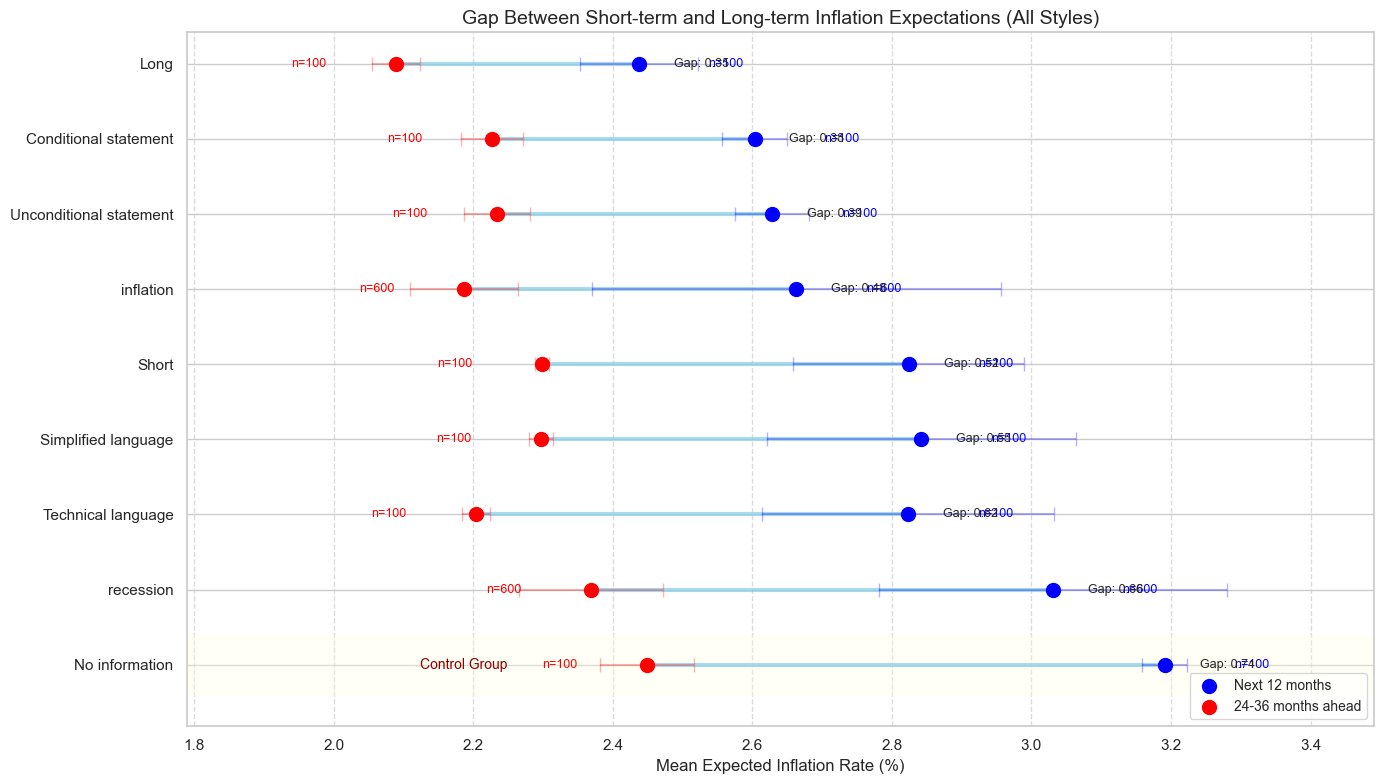

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# Load the original CSV file
df = pd.read_csv('communication_treatments.csv')

# Ensure the response column is numeric
df['response'] = pd.to_numeric(df['response'], errors='coerce')

# Create a simplified version of the question column
df['question_type'] = df['question'].apply(
    lambda x: 'Next 12 months' if 'next 12 months' in x else '24-36 months ahead'
)

# Extract the main communication approach and style from treatment_description
# First, handle the special case for Control
df['approach'] = 'Unknown'  # Default value
df['style'] = 'Unknown'     # Default value

# Handle 'Control with no information' case
mask_control = df['treatment_description'] == 'Control with no information'
df.loc[mask_control, 'approach'] = 'Control'
df.loc[mask_control, 'style'] = 'No information'

# Handle Anti-inflation cases
mask_inflation = df['treatment_description'].str.contains('Anti-inflation', na=False)
df.loc[mask_inflation, 'approach'] = 'Anti-inflation'

# Handle Anti-recession cases
mask_recession = df['treatment_description'].str.contains('Anti-recession', na=False)
df.loc[mask_recession, 'approach'] = 'Anti-recession'

# Handle Neutral cases
mask_neutral = df['treatment_description'].str.contains('Neutral', na=False)
df.loc[mask_neutral, 'approach'] = 'Neutral'

# Extract the style part
# We use a different approach to extract the style part
def extract_style(treatment_desc):
    if treatment_desc == 'Control with no information':
        return 'No information'
    
    parts = treatment_desc.split('-')
    if len(parts) > 1:
        return parts[1].strip()
    else:
        return treatment_desc  # Return original if no split possible

df['style'] = df['treatment_description'].apply(extract_style)

# Create a simple style column that's consistent across approaches
df['simple_style'] = df['style']

# Function to create visualization for each approach
def create_approach_visualization(df, approach_name):
    # Filter data for the approach
    approach_df = df[df['approach'] == approach_name].copy()
    
    # Skip if not enough data
    if len(approach_df) <= 1:
        print(f"Not enough data for {approach_name}")
        return
    
    # Group by style and question_type
    grouped = approach_df.groupby(['style', 'question_type'])['response'].agg([
        ('mean', 'mean'),
        ('median', 'median'),
        ('std', 'std'),
        ('count', 'count')
    ]).reset_index()
    
    # Create a pivot table for the gap calculation
    pivot = grouped.pivot(index='style', columns='question_type', values='mean')
    
    # Only continue if we have both question types
    if 'Next 12 months' in pivot.columns and '24-36 months ahead' in pivot.columns:
        # Calculate gap
        pivot['gap'] = pivot['Next 12 months'] - pivot['24-36 months ahead']
        
        # Sort by gap size
        pivot = pivot.sort_values('gap', ascending=False)
        
        # Prepare data for visualization
        styles = pivot.index.tolist()
        
        # Create figure
        fig, ax = plt.subplots(figsize=(14, max(6, len(styles) * 0.8)))
        
        # Get the data for plotting
        short_term = [pivot.loc[style, 'Next 12 months'] for style in styles]
        long_term = [pivot.loc[style, '24-36 months ahead'] for style in styles]
        
        # Get standard deviations
        std_df = grouped.pivot(index='style', columns='question_type', values='std')
        short_term_std = [std_df.loc[style, 'Next 12 months'] if style in std_df.index and 'Next 12 months' in std_df.columns else 0 for style in styles]
        long_term_std = [std_df.loc[style, '24-36 months ahead'] if style in std_df.index and '24-36 months ahead' in std_df.columns else 0 for style in styles]
        
        # Get counts
        count_df = grouped.pivot(index='style', columns='question_type', values='count')
        short_term_count = [int(count_df.loc[style, 'Next 12 months']) if style in count_df.index and 'Next 12 months' in count_df.columns else 0 for style in styles]
        long_term_count = [int(count_df.loc[style, '24-36 months ahead']) if style in count_df.index and '24-36 months ahead' in count_df.columns else 0 for style in styles]
        
        # Plot the lollipops
        y_pos = np.arange(len(styles))
        ax.hlines(y=y_pos, xmin=long_term, xmax=short_term, color='skyblue', alpha=0.7, linewidth=3)
        ax.scatter(short_term, y_pos, color='blue', s=100, label='Next 12 months', zorder=3)
        ax.scatter(long_term, y_pos, color='red', s=100, label='24-36 months ahead', zorder=3)
        
        # Add error bars
        for i, (short, long, short_std, long_std) in enumerate(zip(short_term, long_term, short_term_std, long_term_std)):
            ax.errorbar(short, i, xerr=short_std, fmt='none', ecolor='blue', alpha=0.3, capsize=5)
            ax.errorbar(long, i, xerr=long_std, fmt='none', ecolor='red', alpha=0.3, capsize=5)
        
        # Add count annotations
        for i, (short, long, short_count, long_count) in enumerate(zip(short_term, long_term, short_term_count, long_term_count)):
            ax.annotate(f"n={short_count}", xy=(short + 0.1, i), fontsize=9, color='blue', ha='left', va='center')
            ax.annotate(f"n={long_count}", xy=(long - 0.1, i), fontsize=9, color='red', ha='right', va='center')
        
        # Add gap sizes
        for i, (short, long) in enumerate(zip(short_term, long_term)):
            gap = short - long
            ax.text(short + 0.05, i, f"Gap: {gap:.2f}", va='center', ha='left', fontsize=9)
        
        # Set labels and title
        ax.set_yticks(y_pos)
        ax.set_yticklabels(styles)
        ax.set_title(f'Gap Between Short-term and Long-term Inflation Expectations - {approach_name}', fontsize=14)
        ax.set_xlabel('Mean Expected Inflation Rate (%)', fontsize=12)
        ax.legend(loc='lower right', fontsize=10)
        ax.grid(axis='x', linestyle='--', alpha=0.7)
        
        # Set x-axis limits with padding
        min_x = min(min(short_term), min(long_term)) - 0.3
        max_x = max(max(short_term), max(long_term)) + 0.3
        ax.set_xlim(min_x, max_x)
        
        plt.tight_layout()
        plt.savefig(f'{approach_name.lower().replace(" ", "_")}_styles.png')
        plt.close()
        
        # Create and print table
        table_data = pivot.reset_index()
        table_data = table_data.round(2)
        print(f"\nGap Analysis for {approach_name}:")
        print(tabulate(table_data, headers='keys', tablefmt='pretty', showindex=False))
        
        # Save table to CSV
        table_data.to_csv(f'{approach_name.lower().replace(" ", "_")}_analysis.csv', index=False)
        
        return table_data
    else:
        print(f"Missing data for one of the question types in {approach_name}")
        return None

# Create visualizations for each approach and the combined data
approaches = ['Anti-inflation', 'Anti-recession', 'Neutral', 'Control']
all_tables = []

for approach in approaches:
    result = create_approach_visualization(df, approach)
    if result is not None:
        all_tables.append(result)

# Now create the combined visualization with all styles
print("\nCreating combined visualization for all styles...")

# Aggregate by style across all approaches
combined_data = df.groupby(['simple_style', 'question_type'])['response'].agg([
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('count', 'count')
]).reset_index()

# Create a pivot table for the gap calculation
combined_pivot = combined_data.pivot(index='simple_style', columns='question_type', values='mean')

# Calculate gap
if 'Next 12 months' in combined_pivot.columns and '24-36 months ahead' in combined_pivot.columns:
    combined_pivot['gap'] = combined_pivot['Next 12 months'] - combined_pivot['24-36 months ahead']
    
    # Sort by gap size
    combined_pivot = combined_pivot.sort_values('gap', ascending=False)
    
    # Prepare data for visualization
    all_styles = combined_pivot.index.tolist()
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, max(8, len(all_styles) * 0.8)))
    
    # Get the data for plotting
    short_term = [combined_pivot.loc[style, 'Next 12 months'] for style in all_styles]
    long_term = [combined_pivot.loc[style, '24-36 months ahead'] for style in all_styles]
    
    # Get standard deviations
    std_df = combined_data.pivot(index='simple_style', columns='question_type', values='std')
    short_term_std = [std_df.loc[style, 'Next 12 months'] if style in std_df.index and 'Next 12 months' in std_df.columns else 0 for style in all_styles]
    long_term_std = [std_df.loc[style, '24-36 months ahead'] if style in std_df.index and '24-36 months ahead' in std_df.columns else 0 for style in all_styles]
    
    # Get counts
    count_df = combined_data.pivot(index='simple_style', columns='question_type', values='count')
    short_term_count = [int(count_df.loc[style, 'Next 12 months']) if style in count_df.index and 'Next 12 months' in count_df.columns else 0 for style in all_styles]
    long_term_count = [int(count_df.loc[style, '24-36 months ahead']) if style in count_df.index and '24-36 months ahead' in count_df.columns else 0 for style in all_styles]
    
    # Plot the lollipops
    y_pos = np.arange(len(all_styles))
    ax.hlines(y=y_pos, xmin=long_term, xmax=short_term, color='skyblue', alpha=0.7, linewidth=3)
    ax.scatter(short_term, y_pos, color='blue', s=100, label='Next 12 months', zorder=3)
    ax.scatter(long_term, y_pos, color='red', s=100, label='24-36 months ahead', zorder=3)
    
    # Add error bars
    for i, (short, long, short_std, long_std) in enumerate(zip(short_term, long_term, short_term_std, long_term_std)):
        ax.errorbar(short, i, xerr=short_std, fmt='none', ecolor='blue', alpha=0.3, capsize=5)
        ax.errorbar(long, i, xerr=long_std, fmt='none', ecolor='red', alpha=0.3, capsize=5)
    
    # Add count annotations
    for i, (short, long, short_count, long_count) in enumerate(zip(short_term, long_term, short_term_count, long_term_count)):
        ax.annotate(f"n={short_count}", xy=(short + 0.1, i), fontsize=9, color='blue', ha='left', va='center')
        ax.annotate(f"n={long_count}", xy=(long - 0.1, i), fontsize=9, color='red', ha='right', va='center')
    
    # Highlight control group if present
    if 'No information' in all_styles:
        control_idx = all_styles.index('No information')
        ax.axhspan(control_idx-0.4, control_idx+0.4, color='lightyellow', alpha=0.3, zorder=1)
        ax.text(long_term[control_idx] - 0.2, control_idx, 'Control Group', fontsize=10, va='center', ha='right', color='darkred')
    
    # Add gap sizes
    for i, (short, long) in enumerate(zip(short_term, long_term)):
        gap = short - long
        ax.text(short + 0.05, i, f"Gap: {gap:.2f}", va='center', ha='left', fontsize=9)
    
    # Set labels and title
    ax.set_yticks(y_pos)
    ax.set_yticklabels(all_styles)
    ax.set_title('Gap Between Short-term and Long-term Inflation Expectations (All Styles)', fontsize=14)
    ax.set_xlabel('Mean Expected Inflation Rate (%)', fontsize=12)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Set x-axis limits with padding
    min_x = min(min(short_term), min(long_term)) - 0.3
    max_x = max(max(short_term), max(long_term)) + 0.3
    ax.set_xlim(min_x, max_x)
    
    plt.tight_layout()
    plt.savefig('combined_styles.png')
    
    # Create and print table
    combined_table = combined_pivot.reset_index()
    combined_table = combined_table.round(2)
    print("\nCombined Analysis for All Styles:")
    print(tabulate(combined_table, headers='keys', tablefmt='pretty', showindex=False))
    
    # Save table to CSV
    combined_table.to_csv('combined_analysis.csv', index=False)

print("\nAll visualizations have been created successfully.")

In [21]:
import pandas as pd
import numpy as np
from tabulate import tabulate

# Load the CSV file
df = pd.read_csv('communication_treatments copy.csv')

# Function to calculate statistics with difference from control
def create_stats_table(dataframe, q_value, group_vars):
    # Filter the dataframe for the specific Q value
    filtered_df = dataframe[dataframe['Q'] == q_value]
    
    # Get the control value first
    control_mean = filtered_df[
        (filtered_df['Type1'] == 'Control') & 
        (filtered_df['Type2'] == 'Control')
    ]['response'].mean()
    
    # Group by the specified variables and calculate statistics
    result = filtered_df.groupby(group_vars)['response'].agg([
        ('Mean', 'mean'),
        ('Median', 'median'),
        ('Std Dev', 'std')
    ]).reset_index()
    
    # Calculate difference from control
    result['Diff vs Control'] = (result['Mean'] - control_mean).round(2)
    
    # Add a + sign to positive differences for better readability
    result['Diff vs Control'] = result['Diff vs Control'].apply(
        lambda x: f"+{x}" if x > 0 else str(x)
    )
    
    # Round the numeric values for better display
    for col in ['Mean', 'Median', 'Std Dev']:
        result[col] = result[col].round(2)
    
    # Format the table using tabulate
    return tabulate(result, headers='keys', tablefmt="grid")

# Create and print all 6 tables

# Table 1: SR by Type1 and Type2
print("\nStatistics for Q = SR grouped by Type1 and Type2:")
print(create_stats_table(df, 'SR', ['Type1', 'Type2']))

# Table 2: LR by Type1 and Type2
print("\nStatistics for Q = LR grouped by Type1 and Type2:")
print(create_stats_table(df, 'LR', ['Type1', 'Type2']))

# Table 3: SR aggregated by Type1
print("\nStatistics for Q = SR aggregated by Type1:")
print(create_stats_table(df, 'SR', ['Type1']))

# Table 4: SR aggregated by Type2
print("\nStatistics for Q = SR aggregated by Type2:")
print(create_stats_table(df, 'SR', ['Type2']))

# Table 5: LR aggregated by Type1
print("\nStatistics for Q = LR aggregated by Type1:")
print(create_stats_table(df, 'LR', ['Type1']))

# Table 6: LR aggregated by Type2
print("\nStatistics for Q = LR aggregated by Type2:")
print(create_stats_table(df, 'LR', ['Type2']))


Statistics for Q = SR grouped by Type1 and Type2:
+----+----------------+-------------------------+--------+----------+-----------+-------------------+
|    | Type1          | Type2                   |   Mean |   Median |   Std Dev |   Diff vs Control |
+====+================+=========================+========+==========+===========+===================+
|  0 | Anti Inflation | Conditional statement   |   2.89 |      2.9 |      0.21 |             -0.3  |
+----+----------------+-------------------------+--------+----------+-----------+-------------------+
|  1 | Anti Inflation | Long-term horizon       |   2.55 |      2.5 |      0.07 |             -0.64 |
+----+----------------+-------------------------+--------+----------+-----------+-------------------+
|  2 | Anti Inflation | Short-term horizon      |   2.55 |      2.6 |      0.07 |             -0.64 |
+----+----------------+-------------------------+--------+----------+-----------+-------------------+
|  3 | Anti Inflation | Simplif